### Generation of synthetic data for biclustering

*   Data matrix with shape (1000 x 1000) and all positive values (>= 0)
*   n_clusters = 3, 5, 10
*   noise such that NMI >= 0.70
*   starting with perfectly balanced row clustering (sensitive_p=0.0), then the sensitive feature Sx is changed
*   number of protected groups = 2, 3

In [1]:
import numpy as np
from sklearn.datasets import make_biclusters
import matplotlib.pyplot as plt
from sklearn.metrics.cluster import normalized_mutual_info_score

import pickle

import sys
sys.path.append('/home/peiretti/fair-clustering/tauCC/src')
from fairness_metrics import balance_gen, balance_chierichetti
from utils import create_path
from taucc.taucc import CoClust

In [2]:
import os

Test make_biclusters on 10 run: standard deviation, normalized mutual information

In [3]:
NUM_ROWS = 1000
NUM_COLS = 1000
NUM_GROUPS_ROWS = 2
NUM_GROUPS_COLS = 2
NUM_CLUSTERS = 3
sensitive_y = True  ### SE SI VUOLE CREARE SY IMPOSTARE A TRUE !!!!!!

In [4]:
if sensitive_y:
    root = os.getcwd() + f"/datasets/synthetic/clus{NUM_CLUSTERS}_rc"
else:
    root = os.getcwd() + f"/datasets/synthetic/clus{NUM_CLUSTERS}"
create_path(root)

Folder '/home/peiretti/fair-clustering/datasets/synthetic/clus3_rw' created successfully.


Generation of a data matrix

In [5]:
root

'/home/peiretti/fair-clustering/datasets/synthetic/clus3_rw'

In [6]:
for noise in np.arange(2.0,0.0,-0.1):
    
    for attempt in range(10):
    
        data, rows, cols = make_biclusters(
            shape=(NUM_ROWS, NUM_COLS), n_clusters=NUM_CLUSTERS, noise=noise, minval=0, maxval=6
        )
        
        data[data <= 0] = 0
        data = np.array(data.astype(int))
        
        if np.all(data >= 0):
            
            std = np.std(data)

            row_labels = np.zeros(data.shape[0], dtype=int)
            for index, clus in enumerate(rows):
                ids = np.where(clus == True)[0]
                row_labels[ids] = index

            col_labels = np.zeros(data.shape[1], dtype=int)
            for index, clus in enumerate(cols):
                ids = np.where(clus == True)[0]
                col_labels[ids] = index

            nmis_rows = []
            nmis_cols = []
            for run in range(10):
                model = CoClust(initialization="random", verbose=True)
                model.fit(data)
                nmi_rows = normalized_mutual_info_score(row_labels, np.array(model.row_labels_))
                nmis_rows.append(nmi_rows)
                nmi_cols = normalized_mutual_info_score(col_labels, np.array(model.column_labels_))
                nmis_cols.append(nmi_cols)

            mean_nmi_rows = np.mean(nmis_rows)
            mean_nmi_cols = np.mean(nmis_cols)

            if mean_nmi_rows >= 0.7 and mean_nmi_cols >= 0.7:

                col_labels = np.zeros(data.shape[1], dtype=int)
                for index, clus in enumerate(cols):
                    ids = np.where(clus == True)[0]
                    col_labels[ids] = index

                results = {
                    'matrix': data,
                    'row_labels': row_labels,
                    'col_labels': col_labels,
                    'noise': noise,
                    'std': std,
                    'mean_nmi_rows': mean_nmi_rows,
                    'mean_nmi_cols': mean_nmi_cols
                }

                with open(root + '/data.pkl', 'wb') as f:
                    pickle.dump(results, f)

                print(f"matrix found: noise = {noise}, std = {std}, nmi_rows = {mean_nmi_rows}, nmi_cols = {mean_nmi_cols}")
                sys.exit(0)


Initialization step for (1000,1000)-siezed input matrix.
iteration 0, moving rows, n_clusters: (27, 30), n_moves: 913
Values of tau_x: 0.0068 and tau_y: 0.0006, for (27,30)-sized T at iteration: 0 (on rows).
iteration 1, moving rows, n_clusters: (9, 30), n_moves: 394
Values of tau_x: 0.0124 and tau_y: 0.0005, for (9,30)-sized T at iteration: 0 (on rows).
iteration 2, moving rows, n_clusters: (5, 30), n_moves: 53
Values of tau_x: 0.0130 and tau_y: 0.0005, for (5,30)-sized T at iteration: 0 (on rows).
iteration 3, moving rows, n_clusters: (4, 30), n_moves: 7
Values of tau_x: 0.0131 and tau_y: 0.0005, for (4,30)-sized T at iteration: 0 (on rows).
iteration 4, moving rows, n_clusters: (4, 30), n_moves: 0
Values of tau_x: 0.0131 and tau_y: 0.0005, for (4,30)-sized T at iteration: 0 (on rows).
iteration 5, moving columns, n_clusters: (4, 2), n_moves: 951
Values of tau_x: 0.3457 and tau_y: 0.3486, for (4,2)-sized T at iteration: 0 (on columns).
iteration 6, moving columns, n_clusters: (4, 2),

iteration 0, moving rows, n_clusters: (29, 30), n_moves: 907
Values of tau_x: 0.0077 and tau_y: 0.0007, for (29,30)-sized T at iteration: 0 (on rows).
iteration 1, moving rows, n_clusters: (4, 30), n_moves: 404
Values of tau_x: 0.0179 and tau_y: 0.0006, for (4,30)-sized T at iteration: 0 (on rows).
iteration 2, moving rows, n_clusters: (3, 30), n_moves: 28
Values of tau_x: 0.0184 and tau_y: 0.0006, for (3,30)-sized T at iteration: 0 (on rows).
iteration 3, moving rows, n_clusters: (3, 30), n_moves: 0
Values of tau_x: 0.0184 and tau_y: 0.0006, for (3,30)-sized T at iteration: 0 (on rows).
iteration 4, moving columns, n_clusters: (3, 2), n_moves: 957
Values of tau_x: 0.3733 and tau_y: 0.3739, for (3,2)-sized T at iteration: 0 (on columns).
iteration 5, moving columns, n_clusters: (3, 2), n_moves: 0
Values of tau_x: 0.3733 and tau_y: 0.3739, for (3,2)-sized T at iteration: 0 (on columns).
iteration 6, moving rows, n_clusters: (2, 2), n_moves: 61
Values of tau_x: 0.3950 and tau_y: 0.3950, 

SystemExit: 0

/home/peiretti/.local/lib/python3.8/site-packages/IPython/core/interactiveshell.py:3259: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [7]:
with open(root + '/data.pkl', 'rb') as f:
    result = pickle.load(f)
    
matrix = result["matrix"]
row_labels = result["row_labels"]
col_labels = result["col_labels"]

print(f"noise: {result['noise']}")
print(f"std: {result['std']}")
print(f"nmi rows: {result['mean_nmi_rows']}")
print(f"nmi cols: {result['mean_nmi_cols']}")

noise: 2.0
std: 1.9727970300058746
nmi rows: 0.7129195166312849
nmi cols: 0.730478220807379


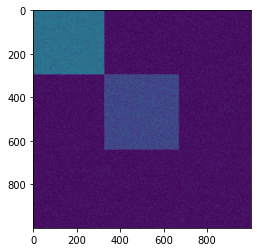

In [8]:
row_indices = np.argsort(row_labels)
col_indices = np.argsort(col_labels)
matrix_reorg = matrix[row_indices, :]
matrix_reorg = matrix_reorg[:, col_indices]
plt.imshow(matrix_reorg)

Generation of perfectly balanced row clustering

*   num_groups: number of protected groups
*   ratios: group ratio in the dataset

In [9]:
def generate_sensitive(num_groups, row_labels):
    
    clusters, counts = np.unique(row_labels, return_counts=True)

    if np.all(counts > 1):
        print("clusters: ", clusters)
        print("counts:   ", counts)

    else:
        clus_one_item = clusters[np.where(counts == 1)[0]]
        print("clusters with a single item: ", clus_one_item)

    num_rows = row_labels.shape[0]

    ratios = [1/num_groups] * num_groups

    Sx = np.zeros((row_labels.shape), dtype=int)

    rng = np.random.default_rng()

    for clus, count in zip(clusters, counts):    
        items = np.where(row_labels == clus)[0]

        for group in range(num_groups):
            num_choices = int(count * ratios[group])
            rng.shuffle(items)
            choices = items[:num_choices]
            Sx[choices] = group
            items = items[num_choices:]

        for item in items:
            Sx[item] = rng.choice(num_groups)

    print("protected groups: ", np.unique(Sx, return_counts=True))
    print("balance: ", balance_gen(Sx, row_labels))
    return Sx

In [10]:
Sx = generate_sensitive(NUM_GROUPS_ROWS, row_labels)
np.unique(Sx, return_counts=True)

clusters:  [0 1 2]
counts:    [295 345 360]
protected groups:  (array([0, 1]), array([499, 501]))
balance:  0.998


(array([0, 1]), array([499, 501]))

In [11]:
if sensitive_y:
    Sy = generate_sensitive(NUM_GROUPS_COLS, col_labels)
    print(np.unique(Sy, return_counts=True))

clusters:  [0 1 2]
counts:    [327 342 331]
protected groups:  (array([0, 1]), array([499, 501]))
balance:  0.998
(array([0, 1]), array([499, 501]))


In [12]:
root

'/home/peiretti/fair-clustering/datasets/synthetic/clus3_rw'

In [13]:
if sensitive_y:
    create_path(root + f"/groups_r{NUM_GROUPS_ROWS}_c{NUM_GROUPS_COLS}")
else:
    create_path(root + f"/groups{NUM_GROUPS_ROWS}")

Folder '/home/peiretti/fair-clustering/datasets/synthetic/clus3_rw/groups_r2_c2' created successfully.


In [14]:
np.save(root + f"/matrix.npy", matrix)
np.save(root + f"/row_labels.npy", row_labels)
np.save(root + f"/col_labels.npy", col_labels)

In [15]:
if sensitive_y:
    np.save(root + f"/groups_r{NUM_GROUPS_ROWS}_c{NUM_GROUPS_COLS}/sx_p0.0.npy", Sx)
    np.save(root + f"/groups_r{NUM_GROUPS_ROWS}_c{NUM_GROUPS_COLS}/sy_p0.0.npy", Sy)
else:
    np.save(root + f"/groups{NUM_GROUPS_ROWS}/sensitive_p0.0.npy", Sx)

Execution of TauCC for checking NMI and Balance

In [16]:
nmis_rows = []
balances_rows = []
nmis_cols = []
balances_cols = []

for i in range(10):
    model = CoClust(initialization="random", verbose=True)
    model.fit(matrix)
    nmi_rows = normalized_mutual_info_score(row_labels, np.array(model.row_labels_))
    nmis_rows.append(nmi_rows)
    balances_rows.append(balance_gen(Sx, np.array(model.row_labels_)))
    
    nmi_cols = normalized_mutual_info_score(col_labels, np.array(model.column_labels_))
    nmis_cols.append(nmi_cols)
    
    if sensitive_y:
        balances_cols.append(balance_gen(Sy, np.array(model.column_labels_)))

Initialization step for (1000,1000)-siezed input matrix.
iteration 0, moving rows, n_clusters: (29, 30), n_moves: 916
Values of tau_x: 0.0029 and tau_y: 0.0005, for (29,30)-sized T at iteration: 0 (on rows).
iteration 1, moving rows, n_clusters: (11, 30), n_moves: 545
Values of tau_x: 0.0078 and tau_y: 0.0004, for (11,30)-sized T at iteration: 0 (on rows).
iteration 2, moving rows, n_clusters: (6, 30), n_moves: 167
Values of tau_x: 0.0097 and tau_y: 0.0004, for (6,30)-sized T at iteration: 0 (on rows).
iteration 3, moving rows, n_clusters: (4, 30), n_moves: 31
Values of tau_x: 0.0099 and tau_y: 0.0003, for (4,30)-sized T at iteration: 0 (on rows).
iteration 4, moving rows, n_clusters: (3, 30), n_moves: 7
Values of tau_x: 0.0100 and tau_y: 0.0003, for (3,30)-sized T at iteration: 0 (on rows).
iteration 5, moving rows, n_clusters: (3, 30), n_moves: 2
Values of tau_x: 0.0100 and tau_y: 0.0003, for (3,30)-sized T at iteration: 0 (on rows).
iteration 6, moving rows, n_clusters: (3, 30), n_m

Initialization step for (1000,1000)-siezed input matrix.
iteration 0, moving rows, n_clusters: (27, 30), n_moves: 895
Values of tau_x: 0.0044 and tau_y: 0.0006, for (27,30)-sized T at iteration: 0 (on rows).
iteration 1, moving rows, n_clusters: (9, 30), n_moves: 504
Values of tau_x: 0.0153 and tau_y: 0.0005, for (9,30)-sized T at iteration: 0 (on rows).
iteration 2, moving rows, n_clusters: (4, 30), n_moves: 46
Values of tau_x: 0.0159 and tau_y: 0.0005, for (4,30)-sized T at iteration: 0 (on rows).
iteration 3, moving rows, n_clusters: (3, 30), n_moves: 3
Values of tau_x: 0.0159 and tau_y: 0.0005, for (3,30)-sized T at iteration: 0 (on rows).
iteration 4, moving rows, n_clusters: (3, 30), n_moves: 0
Values of tau_x: 0.0159 and tau_y: 0.0005, for (3,30)-sized T at iteration: 0 (on rows).
iteration 5, moving columns, n_clusters: (3, 2), n_moves: 965
Values of tau_x: 0.3591 and tau_y: 0.3601, for (3,2)-sized T at iteration: 0 (on columns).
iteration 6, moving columns, n_clusters: (3, 2),

iteration 6, moving rows, n_clusters: (3, 30), n_moves: 1
Values of tau_x: 0.0106 and tau_y: 0.0004, for (3,30)-sized T at iteration: 0 (on rows).
iteration 7, moving rows, n_clusters: (3, 30), n_moves: 0
Values of tau_x: 0.0106 and tau_y: 0.0004, for (3,30)-sized T at iteration: 0 (on rows).
iteration 8, moving columns, n_clusters: (3, 2), n_moves: 957
Values of tau_x: 0.3683 and tau_y: 0.3694, for (3,2)-sized T at iteration: 0 (on columns).
iteration 9, moving columns, n_clusters: (3, 2), n_moves: 0
Values of tau_x: 0.3683 and tau_y: 0.3694, for (3,2)-sized T at iteration: 0 (on columns).
iteration 10, moving rows, n_clusters: (2, 2), n_moves: 75
Values of tau_x: 0.3950 and tau_y: 0.3950, for (2,2)-sized T at iteration: 1 (on rows).
iteration 11, moving rows, n_clusters: (2, 2), n_moves: 0
Values of tau_x: 0.3950 and tau_y: 0.3950, for (2,2)-sized T at iteration: 1 (on rows).
iteration 12, moving columns, n_clusters: (2, 2), n_moves: 0
Values of tau_x: 0.3950 and tau_y: 0.3950, for (

In [17]:
print("--- rows ---")
print("NMI")
print("mean: ", np.mean(nmis_rows))
print("min: ", np.min(nmis_rows))
print("max: ", np.max(nmis_rows))

print("BALANCE")
print("mean: ", np.mean(balances_rows))
print("min: ", np.min(balances_rows))
print("max: ", np.max(balances_rows))

--- rows ---
NMI
mean:  0.7129195166312849
min:  0.7129195166312849
max:  0.7129195166312849
BALANCE
mean:  0.9986073842600456
min:  0.9986073842600456
max:  0.9986073842600456


In [18]:
print("--- cols ---")
print("NMI")
print("mean: ", np.mean(nmis_cols))
print("min: ", np.min(nmis_cols))
print("max: ", np.max(nmis_cols))

if sensitive_y:
    print("BALANCE")
    print("mean: ", np.mean(balances_cols))
    print("min: ", np.min(balances_cols))
    print("max: ", np.max(balances_cols))

--- cols ---
NMI
mean:  0.730478220807379
min:  0.730478220807379
max:  0.730478220807379
BALANCE
mean:  0.998939775575616
min:  0.9989397755756161
max:  0.9989397755756161


Load data matrix

In [19]:
matrix = np.load(root + f"/matrix.npy")
row_labels = np.load(root + f"/row_labels.npy")
col_labels = np.load(root + f"/col_labels.npy")

if sensitive_y:
    Sx = np.load(root + f"/groups_r{NUM_GROUPS_ROWS}_c{NUM_GROUPS_COLS}/sx_p0.0.npy")
    Sy = np.load(root + f"/groups_r{NUM_GROUPS_ROWS}_c{NUM_GROUPS_COLS}/sy_p0.0.npy")
else: 
    Sx = np.load(root + f"/groups{NUM_GROUPS_ROWS}/sensitive_p0.0.npy")

In [20]:
np.unique(Sx, return_counts=True)

(array([0, 1]), array([499, 501]))

In [21]:
if sensitive_y:
    print(np.unique(Sy, return_counts=True))

(array([0, 1]), array([499, 501]))


# Generation of sensitive features Sx (with different sensitive degrees) associated with row entities

In [23]:
rng = np.random.default_rng()
clusters = list(range(NUM_CLUSTERS))

for percent in np.round(np.arange(0.2, 1.2, 0.2), 1):
#for percent in np.round(np.arange(0.1, 1.1, 0.1), 1):
    
    print(f"percent = {percent}")

    if sensitive_y:
        Sx = np.load(root + f"/groups_r{NUM_GROUPS_ROWS}_c{NUM_GROUPS_COLS}/sx_p0.0.npy")
    else: 
        Sx = np.load(root + f"/groups{NUM_GROUPS_ROWS}/sensitive_p0.0.npy")

    random_clus = rng.choice(clusters)
    #print("cluster chosen for swapping ", random_clus)

    group_to_change = rng.choice(list(range(NUM_GROUPS_ROWS)), replace=False)
    #print("protected group chosen for swapping: ", group_to_change)

    items = np.where(row_labels == random_clus)[0] # items in random clus
    items_sens = Sx[items] # protected groups of items in random clus
    items_group = items[np.where(items_sens == group_to_change)[0]] # items with sens=group_to_change in random clus 

    if not np.all(np.isin(items_group, items)):
        raise ValueError("items_group is not a subset of items")

    #print(f"total num items of group {group_to_change} in cluster {random_clus}: {len(items_group)}")

    num_items_to_swap = int(np.floor(len(items_group) * percent))
    items_to_swap = rng.choice(items_group, size=num_items_to_swap, replace=False)

    #print(f"num items from group {group_to_change} to be swap: {num_items_to_swap}")

    num_swapped = 0

    other_clusters = list(set(clusters) - set({random_clus}))
    #print(f"other clusters: {other_clusters}")

    other_groups = list(set(range(NUM_GROUPS_ROWS)) - set({group_to_change}))
    #print(f"other groups: {other_groups}")

    num_items_other_group = int(np.floor(num_items_to_swap / (len(clusters)-1)))
    #print("num items from other group to be selected for each different cluster: ", num_items_other_group)

    dict_swap = {}

    for clus in other_clusters:
        #print(f"cluster {clus}")
        items_clus = np.where(row_labels == clus)[0]
        items_clus_sens = Sx[items_clus]

        rng.shuffle(other_groups)

        for other_group in other_groups:

            items_other_group = items_clus[np.where(items_clus_sens == other_group)[0]]

            if len(items_other_group) >= num_items_other_group:
                #print(f"items from other group {other_group}: {len(items_other_group)}")
                items_chosen_other_group = rng.choice(items_other_group, size=num_items_other_group, replace=False)
                #print(f"items from other group {other_group} chosen: {len(items_chosen_other_group)} = {num_items_other_group}")
                Sx[items_chosen_other_group] = group_to_change

                #print(f"{len(items_chosen_other_group)} items from {other_group} to {group_to_change}")

                if other_group in dict_swap:
                    #print(f"group {other_group} exists in dict_swap.")
                    dict_swap[other_group] += len(items_chosen_other_group)
                else:
                    #print(f"group {other_group} does NOT exist in dict_swap.")
                    dict_swap[other_group] = len(items_chosen_other_group)

                num_swapped += len(items_chosen_other_group)
                #print(dict_swap)
                break

    num_items_missing = num_items_to_swap - num_swapped
    print("num items missing: ", num_items_missing)
    print("num items to swap: ", num_items_to_swap)
    print("num swapped: ", num_swapped)
    print("-----------------")

    if(num_items_missing != 0):
        #print(f"*** items missing: {num_items_missing} ***")

        other_group = rng.choice(other_groups, replace=False)
        #print(f"choose group {other_group}")

        clus = rng.choice(other_clusters, replace=False)
        #print(f"choose cluster {clus}")

        items_clus = np.where(row_labels == clus)[0]
        items_clus_sens = Sx[items_clus]
        items_other_group = items_clus[np.where(items_clus_sens == other_group)[0]]
        items_chosen_other_group = rng.choice(items_other_group, size=num_items_missing, replace=False)

        Sx[items_chosen_other_group] = group_to_change

        num_swapped += len(items_chosen_other_group)

        #print(f"{len(items_chosen_other_group)} items from {other_group} to {group_to_change}")

        if other_group in dict_swap:
            #print(f"group {other_group} exists in dict_swap.")
            dict_swap[other_group] += len(items_chosen_other_group)
        else:
            #print(f"group {other_group} does NOT exist in dict_swap.")
            dict_swap[other_group] = len(items_chosen_other_group)

    num_items_missing = num_items_to_swap - num_swapped
    print("num items missing: ", num_items_missing)
    print("num items to swap: ", num_items_to_swap)
    print("num swapped: ", num_swapped)

    start = 0

    for group in dict_swap:
        end = start + dict_swap[group]
        #print(f"items_to_swap[{start}:{end}] --> group {group}")
        Sx[items_to_swap[start:end]] = group
        start = end

    print("num items to swap: ", num_items_to_swap)
    print("num swapped: ", num_swapped)

    if sensitive_y:
        np.save(root + f"/groups_r{NUM_GROUPS_ROWS}_c{NUM_GROUPS_COLS}/sx_p{percent}.npy", Sx)
    else:
        np.save(root + f"/groups{NUM_GROUPS_ROWS}/sensitive_p{percent}.npy", Sx)
    
    print(np.unique(Sx, return_counts=True))
    
    print("Balance [Bera et al.]: ", balance_gen(Sx, row_labels))
    print("Balance [Chierichetti et al.]: ", balance_chierichetti(Sx, row_labels))
    
    print("**************************************************")

percent = 0.2
num items missing:  0
num items to swap:  36
num swapped:  36
-----------------
num items missing:  0
num items to swap:  36
num swapped:  36
num items to swap:  36
num swapped:  36
(array([0, 1]), array([499, 501]))
Balance [Bera et al.]:  0.7984031936127745
Balance [Chierichetti et al.]:  0.6666666666666666
**************************************************
percent = 0.4
num items missing:  0
num items to swap:  68
num swapped:  68
-----------------
num items missing:  0
num items to swap:  68
num swapped:  68
num items to swap:  68
num swapped:  68
(array([0, 1]), array([499, 501]))
Balance [Bera et al.]:  0.604106764253144
Balance [Chierichetti et al.]:  0.4315352697095436
**************************************************
percent = 0.6
num items missing:  0
num items to swap:  88
num swapped:  88
-----------------
num items missing:  0
num items to swap:  88
num swapped:  88
num items to swap:  88
num swapped:  88
(array([0, 1]), array([499, 501]))
Balance [Bera et a

# Generation of sensitive features Sy (with different sensitive degrees) associated with column entities

In [24]:
if sensitive_y:

    rng = np.random.default_rng()
    clusters = list(range(NUM_CLUSTERS))

    for percent in np.round(np.arange(0.2, 1.2, 0.2), 1):

        print(f"percent = {percent}")

        Sy = np.load(root + f"/groups_r{NUM_GROUPS_ROWS}_c{NUM_GROUPS_COLS}/sy_p0.0.npy")

        random_clus = rng.choice(clusters)
        #print("cluster chosen for swapping ", random_clus)

        group_to_change = rng.choice(list(range(NUM_GROUPS_COLS)), replace=False)
        #print("protected group chosen for swapping: ", group_to_change)

        items = np.where(col_labels == random_clus)[0] # items in random clus
        items_sens = Sy[items] # protected groups of items in random clus
        items_group = items[np.where(items_sens == group_to_change)[0]] # items with sens=group_to_change in random clus 

        if not np.all(np.isin(items_group, items)):
            raise ValueError("items_group is not a subset of items")

        #print(f"total num items of group {group_to_change} in cluster {random_clus}: {len(items_group)}")

        num_items_to_swap = int(np.floor(len(items_group) * percent))
        items_to_swap = rng.choice(items_group, size=num_items_to_swap, replace=False)

        #print(f"num items from group {group_to_change} to be swap: {num_items_to_swap}")

        num_swapped = 0

        other_clusters = list(set(clusters) - set({random_clus}))
        #print(f"other clusters: {other_clusters}")

        other_groups = list(set(range(NUM_GROUPS_COLS)) - set({group_to_change}))
        #print(f"other groups: {other_groups}")

        num_items_other_group = int(np.floor(num_items_to_swap / (len(clusters)-1)))
        #print("num items from other group to be selected for each different cluster: ", num_items_other_group)

        dict_swap = {}

        for clus in other_clusters:
            #print(f"cluster {clus}")
            items_clus = np.where(col_labels == clus)[0]
            items_clus_sens = Sy[items_clus]

            rng.shuffle(other_groups)

            for other_group in other_groups:

                items_other_group = items_clus[np.where(items_clus_sens == other_group)[0]]

                if len(items_other_group) >= num_items_other_group:
                    #print(f"items from other group {other_group}: {len(items_other_group)}")
                    items_chosen_other_group = rng.choice(items_other_group, size=num_items_other_group, replace=False)
                    #print(f"items from other group {other_group} chosen: {len(items_chosen_other_group)} = {num_items_other_group}")
                    Sy[items_chosen_other_group] = group_to_change

                    #print(f"{len(items_chosen_other_group)} items from {other_group} to {group_to_change}")

                    if other_group in dict_swap:
                        #print(f"group {other_group} exists in dict_swap.")
                        dict_swap[other_group] += len(items_chosen_other_group)
                    else:
                        #print(f"group {other_group} does NOT exist in dict_swap.")
                        dict_swap[other_group] = len(items_chosen_other_group)

                    num_swapped += len(items_chosen_other_group)
                    #print(dict_swap)
                    break

        num_items_missing = num_items_to_swap - num_swapped
        print("num items missing: ", num_items_missing)
        print("num items to swap: ", num_items_to_swap)
        print("num swapped: ", num_swapped)
        print("-----------------")

        if(num_items_missing != 0):
            #print(f"*** items missing: {num_items_missing} ***")

            other_group = rng.choice(other_groups, replace=False)
            #print(f"choose group {other_group}")

            clus = rng.choice(other_clusters, replace=False)
            #print(f"choose cluster {clus}")

            items_clus = np.where(col_labels == clus)[0]
            items_clus_sens = Sy[items_clus]
            items_other_group = items_clus[np.where(items_clus_sens == other_group)[0]]
            items_chosen_other_group = rng.choice(items_other_group, size=num_items_missing, replace=False)

            Sy[items_chosen_other_group] = group_to_change

            num_swapped += len(items_chosen_other_group)

            #print(f"{len(items_chosen_other_group)} items from {other_group} to {group_to_change}")

            if other_group in dict_swap:
                #print(f"group {other_group} exists in dict_swap.")
                dict_swap[other_group] += len(items_chosen_other_group)
            else:
                #print(f"group {other_group} does NOT exist in dict_swap.")
                dict_swap[other_group] = len(items_chosen_other_group)

        num_items_missing = num_items_to_swap - num_swapped
        print("num items missing: ", num_items_missing)
        print("num items to swap: ", num_items_to_swap)
        print("num swapped: ", num_swapped)

        start = 0

        for group in dict_swap:
            end = start + dict_swap[group]
            #print(f"items_to_swap[{start}:{end}] --> group {group}")
            Sy[items_to_swap[start:end]] = group
            start = end

        print("num items to swap: ", num_items_to_swap)
        print("num swapped: ", num_swapped)

        np.save(root + f"/groups_r{NUM_GROUPS_ROWS}_c{NUM_GROUPS_COLS}/sy_p{percent}.npy", Sy)
        print(np.unique(Sy, return_counts=True))

        print("Balance [Bera et al.]: ", balance_gen(Sy, col_labels))
        print("Balance [Chierichetti et al.]: ", balance_chierichetti(Sy, col_labels))

        print("**************************************************")


percent = 0.2
num items missing:  0
num items to swap:  32
num swapped:  32
-----------------
num items missing:  0
num items to swap:  32
num swapped:  32
num items to swap:  32
num swapped:  32
(array([0, 1]), array([499, 501]))
Balance [Bera et al.]:  0.8057279935541761
Balance [Chierichetti et al.]:  0.676923076923077
**************************************************
percent = 0.4
num items missing:  0
num items to swap:  66
num swapped:  66
-----------------
num items missing:  0
num items to swap:  66
num swapped:  66
num items to swap:  66
num swapped:  66
(array([0, 1]), array([499, 501]))
Balance [Bera et al.]:  0.5993860833449376
Balance [Chierichetti et al.]:  0.4267241379310345
**************************************************
percent = 0.6
num items missing:  1
num items to swap:  99
num swapped:  98
-----------------
num items missing:  0
num items to swap:  99
num swapped:  99
num items to swap:  99
num swapped:  99
(array([0, 1]), array([499, 501]))
Balance [Bera et a

# Test

In [ ]:
import numpy as np
from sklearn.datasets import make_biclusters
import matplotlib.pyplot as plt
from sklearn.metrics.cluster import normalized_mutual_info_score
import os
import pickle

import sys
sys.path.append('/home/peiretti/fair-clustering/tauCC/src')
from fairness_metrics import balance_gen, balance_chierichetti

In [ ]:
NUM_CLUSTERS = 3
NUM_GROUPS_ROWS = NUM_GROUPS_COLS = 2

In [ ]:
path = os.getcwd() + f"/datasets/synthetic/clus{NUM_CLUSTERS}_rw"
path

In [ ]:
matrix = np.load(path + "/matrix.npy")
matrix.shape

In [ ]:
np.unique(matrix)

In [ ]:
row_labels = np.load(path + "/row_labels.npy")
row_labels.shape

In [ ]:
col_labels = np.load(path + "/col_labels.npy")
col_labels.shape

In [ ]:
Sx = np.load(path + f"/groups_r{NUM_GROUPS_ROWS}_c{NUM_GROUPS_COLS}/sx_p0.8.npy")
Sy = np.load(path + f"/groups_r{NUM_GROUPS_ROWS}_c{NUM_GROUPS_COLS}/sy_p0.8.npy")
print("Sx: ", Sx.shape)
print(np.unique(Sx, return_counts=True))
print("Sy: ", Sy.shape)
print(np.unique(Sy, return_counts=True))

In [ ]:
from taucc.taucc import CoClust

model = CoClust(initialization="random", verbose=True)
model.fit(matrix)

In [ ]:
row_clus = model.row_labels_
col_clus = model.column_labels_

In [ ]:
bera_rows = balance_gen(Sx, row_clus)
ch_rows = balance_chierichetti(Sx, row_clus)
nmi_rows = normalized_mutual_info_score(row_labels, row_clus)

print("--- rows ---")
print(f"nmi: {nmi_rows}")
print(f"bera: {bera_rows}")
print(f"chierichetti: {ch_rows}")

In [ ]:
bera_cols = balance_gen(Sy, col_clus)
ch_cols = balance_chierichetti(Sy, col_clus)
nmi_cols = normalized_mutual_info_score(col_labels, col_clus)

print("--- cols ---")
print(f"nmi: {nmi_cols}")
print(f"bera: {bera_cols}")
print(f"chierichetti: {ch_cols}")

In [ ]:
from taucc.taucc_fair_rows_cols import FairCoclus

model = FairCoclus(initialization="random", verbose=True)
model.fit(matrix, Sx, Sy, np.array([1.0,1.0]), np.array([1.0,1.0]))

In [ ]:
fair_row_clus = model.row_labels_
fair_col_clus = model.column_labels_

In [ ]:
fair_bera_rows = balance_gen(Sx, fair_row_clus)
fair_ch_rows = balance_chierichetti(Sx, fair_row_clus)
fair_nmi_rows = normalized_mutual_info_score(row_labels, fair_row_clus)

print("--- rows ---")
print(f"nmi: {fair_nmi_rows}")
print(f"bera: {fair_bera_rows}")
print(f"chierichetti: {fair_ch_rows}")

In [ ]:
fair_bera_cols = balance_gen(Sy, fair_col_clus)
fair_ch_cols = balance_chierichetti(Sy, fair_col_clus)
fair_nmi_cols = normalized_mutual_info_score(col_labels, fair_col_clus)

print("--- cols ---")
print(f"nmi: {fair_nmi_cols}")
print(f"bera: {fair_bera_cols}")
print(f"chierichetti: {fair_ch_cols}")